# ResNet34 224 — pipeline end-to-end para detecção de rosto sintético

Este notebook começa no dataset cru (`training/dataset`), aplica YuNet para localizar uma única face, cria crops PNG quadrados com margem de 15%, audita os dados, divide as partições, treina e salva um artefato autocontido.

Ele compara dois cenários:

1. `random_image`: referência interna; imagens são separadas aleatoriamente e **não prova** generalização por fonte.
2. `source_holdout`: teste mais realista; uma fonte sintética e uma fonte real inteiras ficam fora do treino.

O teste nunca é usado para escolher época, arquitetura ou limiar. A validação escolhe o checkpoint e o limiar.

In [10]:
from __future__ import annotations

import copy
import io
import hashlib
import json
import os
import random
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

SEED = 42
IMAGE_SIZE = 224
FACE_MARGIN = 0.15
FACE_DETECTOR_SCORE_THRESHOLD = 0.9
BATCH_SIZE = 32                 # reduza para 16 se faltar memória de GPU
NUM_WORKERS = 0                 # use 0 no primeiro experimento; aumente após confirmar estabilidade
EPOCHS = 30
PATIENCE = 7
HEAD_EPOCHS = 3
LR_HEAD = 2e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.02
GRADIENT_CLIP_NORM = 1.0
USE_SOURCE_BALANCED_SAMPLER = True
JPEG_AUGMENTATION_PROBABILITY = 0.25

if Path.cwd().name == 'notebooks':
    TRAINING_DIR = Path.cwd().parent
elif (Path.cwd() / 'dataset').is_dir() and (Path.cwd() / 'scripts').is_dir():
    TRAINING_DIR = Path.cwd()
else:
    TRAINING_DIR = Path('training')
PROJECT_DIR = TRAINING_DIR.parent
RAW_DATASET_DIR = TRAINING_DIR / 'dataset'
# Nova pasta exclusiva deste pipeline; a pasta antiga não é consumida por este notebook.
CROPS_DIR = TRAINING_DIR / 'dataset_faces_224_m15_yunet_v1'
REBUILD_CROPS = False            # True força recriar todos os crops a partir do dataset cru
MODELS_DIR = PROJECT_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if str(TRAINING_DIR) not in sys.path:
    sys.path.insert(0, str(TRAINING_DIR))
from scripts.face_detector import FaceDetector

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f'Device: {DEVICE}')
print(f'Dataset cru: {RAW_DATASET_DIR.resolve()}')
print(f'Crops deste pipeline: {CROPS_DIR.resolve()}')
assert RAW_DATASET_DIR.is_dir(), 'Dataset cru não encontrado em training/dataset.'


Device: cuda
Dataset cru: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset
Crops deste pipeline: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset_faces_224_m15_yunet_v1


## Pré-processamento end-to-end com YuNet

Esta etapa é a única origem dos dados de treino. Cada imagem do dataset cru recebe no máximo um crop: imagens sem face, com múltiplas faces ou com falha de leitura são registradas no manifesto e excluídas de forma explícita.

Os crops são PNG quadrados de 224×224. O cache é reutilizado apenas quando `REBUILD_CROPS=False`; use `True` ao trocar detector, margem, tamanho ou dataset cru.

In [2]:
CLASS_NAMES = ['fake', 'real']
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

raw_dataset = ImageFolder(RAW_DATASET_DIR)
assert raw_dataset.classes == CLASS_NAMES, (
    f'Classes inesperadas: {raw_dataset.classes}. Esperadas: {CLASS_NAMES}.'
)

# Detecta colisões de nome antes de escrever crops. Não sobrescreva uma imagem por outra.
output_paths = {}
for source_path, label in raw_dataset.samples:
    source_path = Path(source_path)
    output_path = CROPS_DIR / raw_dataset.classes[label] / f'{source_path.stem}.png'
    if output_path in output_paths:
        raise RuntimeError(
            f'Colisão de nomes: {source_path} e {output_paths[output_path]} gerariam {output_path}. '
            'Renomeie os arquivos de origem antes de continuar.'
        )
    output_paths[output_path] = source_path

face_detector = FaceDetector(score_threshold=FACE_DETECTOR_SCORE_THRESHOLD)
preprocessing_rows = []

for source_path, label in tqdm(
    raw_dataset.samples, desc='Criando/verificando crops YuNet', unit='imagem'
):
    source_path = Path(source_path)
    class_name = raw_dataset.classes[label]
    output_path = CROPS_DIR / class_name / f'{source_path.stem}.png'
    output_path.parent.mkdir(parents=True, exist_ok=True)

    row = {
        'source_path': str(source_path),
        'crop_path': str(output_path),
        'class_name': class_name,
        'label': label,
        'source': source_path.stem.split('_', maxsplit=1)[1],
        'status': 'valid',
        'created_or_rebuilt': False,
    }

    if output_path.is_file() and not REBUILD_CROPS:
        preprocessing_rows.append(row)
        continue

    image = cv2.imread(str(source_path))
    if image is None:
        row['status'] = 'read_error'
        preprocessing_rows.append(row)
        continue

    crop, status = face_detector.crop_face(image, margin=FACE_MARGIN)
    if status != 'valid' or crop is None:
        row['status'] = status
        preprocessing_rows.append(row)
        continue

    crop = cv2.resize(crop, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    temporary_path = output_path.with_suffix('.tmp.png')
    if not cv2.imwrite(str(temporary_path), crop):
        row['status'] = 'write_error'
        preprocessing_rows.append(row)
        continue
    temporary_path.replace(output_path)
    row['created_or_rebuilt'] = True
    preprocessing_rows.append(row)

preprocessing_manifest = pd.DataFrame(preprocessing_rows)
manifest_path = CROPS_DIR / 'preprocessing_manifest.csv'
preprocessing_manifest.to_csv(manifest_path, index=False)

valid_rows = preprocessing_manifest.query("status == 'valid'").copy()
rejected_rows = preprocessing_manifest.query("status != 'valid'").copy()
assert valid_rows['crop_path'].map(lambda crop_path: Path(crop_path).is_file()).all(), 'Há crops válidos ausentes.'
print(f'Imagens cruas: {len(preprocessing_manifest):,}')
print(f'Crops válidos: {len(valid_rows):,}')
print(f'Rejeitadas: {len(rejected_rows):,}')
print(f'Manifesto de pré-processamento: {manifest_path}')
if not rejected_rows.empty:
    display(rejected_rows.groupby(['class_name', 'status']).size().rename('images').to_frame())

frame = valid_rows.rename(columns={'crop_path': 'path'})[
    ['path', 'label', 'class_name', 'source', 'source_path']
].reset_index(drop=True)
display(frame.groupby(['class_name', 'source']).size().rename('images').to_frame())


[ WARN:0@12.697] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


Criando/verificando crops YuNet:   0%|          | 0/16000 [00:00<?, ?imagem/s]

Imagens cruas: 16,000
Crops válidos: 15,960
Rejeitadas: 40
Manifesto de pré-processamento: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset_faces_224_m15_yunet_v1/preprocessing_manifest.csv


images
class_name status                
fake       multiple_faces       2
real       multiple_faces      27
           no_face             11

images
class_name source           
fake       sd_14        2000
           sd_21        2000
           stylegan2    1999
           stylegan3    1999
real       celebhq      1990
           ffhq         5972

## Auditoria antes da divisão

A auditoria encontra duplicatas binárias entre os crops produzidos neste pipeline. Ela não substitui uma tabela de identidade/linhagem: se houver múltiplas imagens da mesma pessoa ou derivações da mesma imagem, forneça um `group_id` real e divida por grupo.

In [3]:
def sha256_file(path: str) -> str:
    digest = hashlib.sha256()
    with open(path, 'rb') as file:
        for block in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

hashes = frame['path'].map(sha256_file)
duplicates = frame.assign(sha256=hashes).duplicated('sha256', keep=False)
print(f'Duplicatas binárias: {duplicates.sum():,}')
assert not duplicates.any(), 'Remova ou agrupe duplicatas antes de treinar.'

# Registre a composição exata derivada do dataset cru.
dataset_manifest_path = MODELS_DIR / 'resnet34_224_dataset_manifest.csv'
frame.sort_values('path').to_csv(dataset_manifest_path, index=False)
print(f'Manifesto salvo em: {dataset_manifest_path}')


Duplicatas binárias: 0
Manifesto salvo em: /home/guilhermemathiasreis/Documents/synthetic-face-detection/models/resnet34_224_dataset_manifest.csv


## Cenários de divisão

`random_image` serve somente como baseline comparável aos seus notebooks anteriores. `source_holdout` é a métrica recomendada para decidir se o modelo generaliza para fontes não vistas. Neste exemplo, SD 2.1 e CelebA-HQ são o teste; altere as fontes e repita em rodízio para medir todos os domínios.

In [4]:
def make_random_split(data: pd.DataFrame):
    train, temporary = train_test_split(
        data, test_size=0.40, stratify=data['label'], random_state=SEED,
    )
    validation, test = train_test_split(
        temporary, test_size=0.50, stratify=temporary['label'], random_state=SEED,
    )
    return train.copy(), validation.copy(), test.copy()


def make_source_holdout_split(data: pd.DataFrame, fake_test_source: str, real_test_source: str):
    test_mask = ((data.class_name == 'fake') & (data.source == fake_test_source)) | (
        (data.class_name == 'real') & (data.source == real_test_source)
    )
    test = data.loc[test_mask].copy()
    remaining = data.loc[~test_mask].copy()
    assert set(test.class_name) == set(CLASS_NAMES), 'O teste precisa conter ambas as classes.'
    train, validation = train_test_split(
        remaining, test_size=0.20, stratify=remaining['label'], random_state=SEED,
    )
    return train.copy(), validation.copy(), test

SCENARIO = 'source_holdout'  # escolha: 'random_image' ou 'source_holdout'
HOLDOUT_FAKE_SOURCE = 'sd_21'
HOLDOUT_REAL_SOURCE = 'celebhq'

if SCENARIO == 'random_image':
    train_df, validation_df, test_df = make_random_split(frame)
elif SCENARIO == 'source_holdout':
    train_df, validation_df, test_df = make_source_holdout_split(
        frame, HOLDOUT_FAKE_SOURCE, HOLDOUT_REAL_SOURCE,
    )
else:
    raise ValueError('SCENARIO inválido.')

for name, split in {'train': train_df, 'validation': validation_df, 'test': test_df}.items():
    print(f'\n{name}: {len(split):,}')
    display(split.groupby(['class_name', 'source']).size().rename('images').to_frame())

# Invariantes de isolamento: nenhum caminho pode existir em duas partições.
train_paths, val_paths, test_paths = map(set, (train_df.path, validation_df.path, test_df.path))
assert not train_paths & val_paths and not train_paths & test_paths and not val_paths & test_paths
if SCENARIO == 'source_holdout':
    assert HOLDOUT_FAKE_SOURCE not in set(train_df.query("class_name == 'fake'").source)
    assert HOLDOUT_REAL_SOURCE not in set(train_df.query("class_name == 'real'").source)

# A associação exata imagem→partição é parte do experimento e deve ser preservada.
split_manifest = pd.concat([
    train_df.assign(split='train'),
    validation_df.assign(split='validation'),
    test_df.assign(split='test'),
]).sort_values('path')
split_manifest_path = MODELS_DIR / f'resnet34_224_{SCENARIO}_seed{SEED}_splits.csv'
split_manifest.to_csv(split_manifest_path, index=False)
print(f'Manifesto de partições: {split_manifest_path}')



train: 9,576


images
class_name source           
fake       sd_14        1612
           stylegan2    1581
           stylegan3    1605
real       ffhq         4778


validation: 2,394


images
class_name source           
fake       sd_14         388
           stylegan2     418
           stylegan3     394
real       ffhq         1194


test: 3,990


,,images
class_name,source,
fake,sd_21,2000
real,celebhq,1990


Manifesto de partições: /home/guilhermemathiasreis/Documents/synthetic-face-detection/models/resnet34_224_source_holdout_seed42_splits.csv


In [5]:
# A célula permanece executável após reiniciar o kernel mesmo se a célula de preparação for pulada.
if "FaceDataset" not in globals():
    class FaceDataset(Dataset):
        def __init__(self, records: list[dict], transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            record = self.records[index]
            with Image.open(record['path']) as image:
                image = image.convert('RGB')
            return self.transform(image), record['label']

class RandomJPEGCompression:
    """Simula recompressão comum de upload/redes sociais sem tocar validação/teste."""
    def __init__(self, probability=0.25, quality_range=(60, 95)):
        self.probability = probability
        self.quality_range = quality_range

    def __call__(self, image):
        if random.random() >= self.probability:
            return image
        quality = random.randint(*self.quality_range)
        buffer = io.BytesIO()
        image.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        with Image.open(buffer) as recompressed:
            return recompressed.convert('RGB')


normalize = transforms.Normalize(mean=MEAN, std=STD)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=3, translate=(0.03, 0.03), scale=(0.97, 1.03)),
    transforms.RandomApply([transforms.ColorJitter(0.06, 0.06, 0.04, 0.01)], p=0.35),
    RandomJPEGCompression(JPEG_AUGMENTATION_PROBABILITY),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))], p=0.10),
    transforms.ToTensor(), normalize,
])
eval_transform = transforms.Compose([transforms.ToTensor(), normalize])

train_records = train_df.to_dict('records')
if USE_SOURCE_BALANCED_SAMPLER:
    # Mantém 50% fake/50% real e distribui igualmente as fontes dentro de cada classe.
    class_counts = train_df.groupby('class_name').size().to_dict()
    sources_per_class = train_df.groupby('class_name')['source'].nunique().to_dict()
    group_counts = train_df.groupby(['class_name', 'source']).size().to_dict()
    sample_weights = [
        1.0 / (
            class_counts[row['class_name']]
            * sources_per_class[row['class_name']]
            * group_counts[(row['class_name'], row['source'])]
        )
        for row in train_records
    ]
    train_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(train_records),
        replacement=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    train_loader = DataLoader(FaceDataset(train_records, train_transform), BATCH_SIZE,
                              sampler=train_sampler, shuffle=False, num_workers=NUM_WORKERS,
                              pin_memory=DEVICE.type == 'cuda')
else:
    train_loader = DataLoader(FaceDataset(train_records, train_transform), BATCH_SIZE,
                              shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=DEVICE.type == 'cuda')

validation_loader = DataLoader(FaceDataset(validation_df.to_dict('records'), eval_transform), BATCH_SIZE,
                               shuffle=False, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
test_loader = DataLoader(FaceDataset(test_df.to_dict('records'), eval_transform), BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
print(f'Sampler balanceado por fonte: {USE_SOURCE_BALANCED_SAMPLER}')


Sampler balanceado por fonte: True


## ResNet34 e fine-tuning com regularização de domínio

A fase inicial adapta somente a cabeça; depois toda a rede é ajustada com learning rate menor no backbone. O treino usa amostragem balanceada por classe e fonte, para que FFHQ não domine a representação real. Augmentations leves simulam variações de câmera e compressão sem destruir completamente os artefatos forenses.

In [6]:
def build_model():
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
    return model.to(DEVICE)

model = build_model()
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

for parameter in model.parameters():
    parameter.requires_grad = False
for parameter in model.fc.parameters():
    parameter.requires_grad = True

optimizer = optim.AdamW(model.fc.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
print('Fase 1: somente a camada final treinável.')


Fase 1: somente a camada final treinável.


In [7]:
@torch.inference_mode()
def predict_loader(loader):
    model.eval()
    targets, probabilities = [], []
    for images, labels in loader:
        logits = model(images.to(DEVICE, non_blocking=True))
        probabilities.extend(torch.softmax(logits, dim=1)[:, CLASS_TO_INDEX['fake']].cpu().numpy())
        targets.extend(labels.numpy())
    return np.asarray(targets), np.asarray(probabilities)


def one_epoch(loader, backbone_frozen: bool = False):
    model.train()
    # Com backbone congelado, BatchNorm também deve permanecer em avaliação;
    # caso contrário suas estatísticas seriam alteradas mesmo sem gradientes.
    if backbone_frozen:
        for module in model.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm):
                module.eval()
    total_loss, total = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total += labels.size(0)
    return total_loss / total

history = []
best_loss = float('inf')
best_state = None
stale_epochs = 0
scheduler = None

for epoch in range(1, EPOCHS + 1):
    if epoch == HEAD_EPOCHS + 1:
        for parameter in model.parameters():
            parameter.requires_grad = True
        backbone_parameters = [
            parameter for name, parameter in model.named_parameters()
            if not name.startswith('fc.')
        ]
        optimizer = optim.AdamW([
            {'params': backbone_parameters, 'lr': LR_BACKBONE},
            {'params': model.fc.parameters(), 'lr': LR_HEAD},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)
        stale_epochs = 0  # a paciência começa novamente ao mudar de fase
        print('Fase 2: fine-tuning completo iniciado.')

    train_loss = one_epoch(train_loader, backbone_frozen=epoch <= HEAD_EPOCHS)
    validation_targets, validation_probabilities = predict_loader(validation_loader)
    model.eval()
    ce_sum, ce_count = 0.0, 0
    with torch.inference_mode():
        for images, labels in validation_loader:
            loss = criterion(model(images.to(DEVICE)), labels.to(DEVICE))
            ce_sum += loss.item() * labels.size(0); ce_count += labels.size(0)
    validation_loss = ce_sum / ce_count
    validation_accuracy = 100 * ((validation_probabilities >= 0.5) == (validation_targets == CLASS_TO_INDEX['fake'])).mean()
    validation_auc = roc_auc_score(validation_targets == CLASS_TO_INDEX['fake'], validation_probabilities)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'validation_loss': validation_loss,
                    'validation_accuracy': validation_accuracy, 'validation_auc': validation_auc})
    print(f'Epoch {epoch:02d} | train loss {train_loss:.4f} | val loss {validation_loss:.4f} | val acc {validation_accuracy:.2f}% | val AUC {validation_auc:.4f}')

    if scheduler is not None:
        scheduler.step(validation_loss)
    if validation_loss < best_loss - 1e-4:
        best_loss, best_state, stale_epochs = validation_loss, copy.deepcopy(model.state_dict()), 0
    else:
        stale_epochs += 1
        if epoch > HEAD_EPOCHS and stale_epochs >= PATIENCE:
            print('Early stopping.'); break

assert best_state is not None
model.load_state_dict(best_state)
history = pd.DataFrame(history)
display(history)


Epoch 01 | train loss 0.5092 | val loss 0.4067 | val acc 83.46% | val AUC 0.9178
Epoch 02 | train loss 0.3920 | val loss 0.3708 | val acc 84.38% | val AUC 0.9307
Epoch 03 | train loss 0.3717 | val loss 0.3535 | val acc 85.09% | val AUC 0.9367
Fase 2: fine-tuning completo iniciado.
Epoch 04 | train loss 0.3017 | val loss 0.2291 | val acc 92.19% | val AUC 0.9774
Epoch 05 | train loss 0.2012 | val loss 0.1909 | val acc 94.70% | val AUC 0.9861
Epoch 06 | train loss 0.1691 | val loss 0.1778 | val acc 95.03% | val AUC 0.9899
Epoch 07 | train loss 0.1452 | val loss 0.1696 | val acc 95.36% | val AUC 0.9913
Epoch 08 | train loss 0.1252 | val loss 0.1561 | val acc 96.24% | val AUC 0.9928
Epoch 09 | train loss 0.1235 | val loss 0.1469 | val acc 96.49% | val AUC 0.9946
Epoch 10 | train loss 0.1107 | val loss 0.1437 | val acc 96.78% | val AUC 0.9947
Epoch 11 | train loss 0.1033 | val loss 0.1431 | val acc 96.62% | val AUC 0.9945
Epoch 12 | train loss 0.0929 | val loss 0.1369 | val acc 96.91% | val 

,epoch,train_loss,validation_loss,validation_accuracy,validation_auc
0,1,0.509198,0.406746,83.458647,0.917825
1,2,0.392007,0.370784,84.377611,0.930734
2,3,0.371748,0.353520,85.087719,0.936717
3,4,0.301695,0.229067,92.188805,0.977432
4,5,0.201246,0.190860,94.695071,0.986122
5,6,0.169119,0.177784,95.029240,0.989881
6,7,0.145207,0.169582,95.363409,0.991286
7,8,0.125206,0.156134,96.240602,0.992830
8,9,0.123475,0.146947,96.491228,0.994585
9,10,0.110691,0.143682,96.783626,0.994704


In [12]:
validation_targets, validation_probabilities = predict_loader(validation_loader)
thresholds = np.linspace(0.01, 0.99, 99)
validation_f2 = [fbeta_score(validation_targets == CLASS_TO_INDEX['fake'], validation_probabilities >= t, beta=2) for t in thresholds]
threshold = float(thresholds[int(np.argmax(validation_f2))])

# O teste é intocado até esta célula.
test_targets, test_probabilities = predict_loader(test_loader)
test_predictions = np.where(test_probabilities >= threshold, CLASS_TO_INDEX['fake'], CLASS_TO_INDEX['real'])

print(f'Limiar selecionado na validação: P(fake) >= {threshold:.2f}')
print(f'ROC-AUC teste: {roc_auc_score(test_targets == CLASS_TO_INDEX["fake"], test_probabilities):.4f}')
print(f'PR-AUC teste:  {average_precision_score(test_targets == CLASS_TO_INDEX["fake"], test_probabilities):.4f}')
print(classification_report(test_targets, test_predictions, target_names=CLASS_NAMES, digits=4))
print('Matriz [real do eixo linha; previsto no eixo coluna]:')
print(confusion_matrix(test_targets, test_predictions, labels=[CLASS_TO_INDEX['fake'], CLASS_TO_INDEX['real']]))

Limiar selecionado na validação: P(fake) >= 0.20
ROC-AUC teste: 0.9933
PR-AUC teste:  0.9939
              precision    recall  f1-score   support

        fake     0.9563    0.9635    0.9599      2000
        real     0.9630    0.9558    0.9594      1990

    accuracy                         0.9596      3990
   macro avg     0.9597    0.9596    0.9596      3990
weighted avg     0.9597    0.9596    0.9596      3990

Matriz [real do eixo linha; previsto no eixo coluna]:
[[1927   73]
 [  88 1902]]


## Matrizes de confusão e diagnóstico por fonte

A matriz em contagem mostra o número absoluto de erros. A matriz normalizada por linha mostra o recall de cada classe e evita que uma classe maior esconda erros da outra. O resumo por fonte revela se o desempenho está concentrado em um domínio específico.

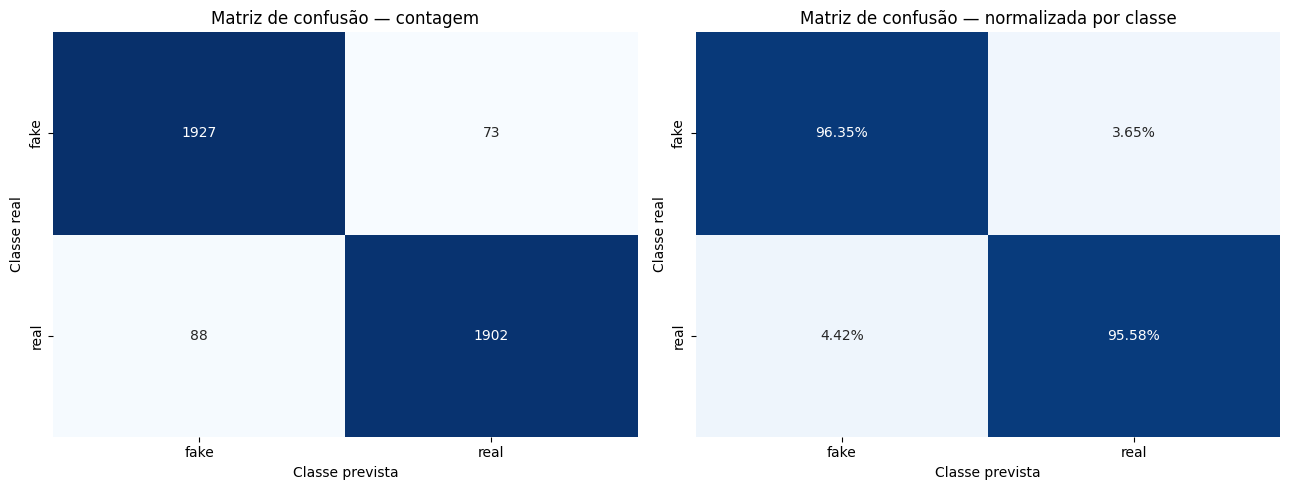

,,images,accuracy,probability_fake_mean
class_name,source,,,
fake,sd_21,2000,96.35%,0.897
real,celebhq,1990,95.58%,0.037


In [13]:
labels_order = [CLASS_TO_INDEX['fake'], CLASS_TO_INDEX['real']]
display_labels = ['fake', 'real']

cm_counts = confusion_matrix(test_targets, test_predictions, labels=labels_order)
cm_normalized = confusion_matrix(
    test_targets, test_predictions, labels=labels_order, normalize='true',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, matrix, title, fmt in [
    (axes[0], cm_counts, 'Matriz de confusão — contagem', 'd'),
    (axes[1], cm_normalized, 'Matriz de confusão — normalizada por classe', '.2%'),
]:
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap='Blues', cbar=False,
        xticklabels=display_labels, yticklabels=display_labels, ax=axis,
        vmin=0 if fmt == '.2%' else None, vmax=1 if fmt == '.2%' else None,
    )
    axis.set_xlabel('Classe prevista')
    axis.set_ylabel('Classe real')
    axis.set_title(title)

plt.tight_layout()
plt.show()

# Métricas desagregadas: fundamentais no cenário source_holdout.
test_report = test_df[['path', 'class_name', 'source']].copy().reset_index(drop=True)
test_report['probability_fake'] = test_probabilities
test_report['prediction'] = [CLASS_NAMES[index] for index in test_predictions]
test_report['correct'] = test_report['prediction'].eq(test_report['class_name'])

source_summary = (
    test_report.groupby(['class_name', 'source'])
    .agg(
        images=('correct', 'size'),
        accuracy=('correct', 'mean'),
        probability_fake_mean=('probability_fake', 'mean'),
    )
    .sort_index()
)

display(
    source_summary.style.format({
        'accuracy': '{:.2%}',
        'probability_fake_mean': '{:.3f}',
    })
)

## Salvar artefato autocontido

O arquivo inclui pesos, ordem dos rótulos, normalização, tamanho e contrato do crop. A API deve carregar este dicionário e aplicar `YuNet (score 0,9) → uma face → margem 0,15 → RGB → resize 224 → normalização ImageNet`; ela não deve usar a configuração atual de 256 px para este artefato.

In [ ]:
artifact = {
    'state_dict': model.state_dict(),
    'architecture': 'resnet34',
    'image_size': IMAGE_SIZE,
    'class_names': CLASS_NAMES,
    'class_to_index': CLASS_TO_INDEX,
    'normalization': {'mean': MEAN, 'std': STD},
    'fake_probability_threshold': threshold,
    'threshold_selection': {
        'dataset': 'validation',
        'metric': 'fbeta',
        'beta': 2,
        'positive_class': 'fake',
    },
    'face_crop': {
        'detector': 'YuNet face_detection_yunet_2023mar.onnx',
        'score_threshold': FACE_DETECTOR_SCORE_THRESHOLD,
        'single_face_only': True,
        'margin': FACE_MARGIN,
        'crop_shape': 'square',
        'preprocessing_manifest': str(manifest_path),
    },
}
artifact_path = MODELS_DIR / f'resnet34_224.pt'
torch.save(artifact, artifact_path)
with open(artifact_path.with_suffix('.json'), 'w', encoding='utf-8') as file:
    json.dump({key: value for key, value in artifact.items() if key != 'state_dict'}, file, indent=2)
print(f'Modelo: {artifact_path}')
print(f'Metadados: {artifact_path.with_suffix(".json")}')


Modelo: /home/guilhermemathiasreis/Documents/synthetic-face-detection/models/resnet34_224_source_holdout_seed42.pt
Metadados: /home/guilhermemathiasreis/Documents/synthetic-face-detection/models/resnet34_224_source_holdout_seed42.json
